In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
%matplotlib inline

# Baseline Figures Comparison

In [3]:
# Experiment Name and Locations
exp = "tf-tc-ybco_delft-hemt-lp_ybco-kide"
fname = PROJ_ROOT_PATH / "notebooks" / "experiments" / "directions" / "kide" / "ybco_delft" / exp / f"{exp}.pkl"
pqfname =  PROJ_ROOT_PATH / "notebooks" / "experiments" / "directions" / "kide" / "ybco_delft" / exp/ f"PQ_{exp}.pkl"
df =  pd.read_pickle(fname)
df_pq =  pd.read_pickle(pqfname)
pq = df_pq.iloc[0].tolist()
title = "KIDE with Ag-YBCO-NbTi Microwave Striplines"

In [4]:
from library.utils import fontstyle, style_map

title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# Define fallbacks (only used if a stack tuple isn’t in style_map)
# fallback_colors = plt.cm.tab20.colors  # a nice, long qualitative palette
# fallback_hatches = ['/', '\\', 'x', '-', '+', 'o', 'O', '.', '*']  # repeats cyclically
fallback_color = 'white' 
fallback_hatch = '//'  

In [5]:
df

Cable,DRIVE,FLUX_BIAS,COUPLER,PUMP,READOUT_PIN,READOUT_POUT,AMP_BIAS,AMP_BIAS_50K,DC_TERMINAL,DRIVE,FLUX_BIAS,COUPLER,PUMP,READOUT_PIN,AMP_BIAS,AMP_BIAS_50K,Total
Component,PASSIVE,PASSIVE,PASSIVE,PASSIVE,PASSIVE,PASSIVE,PASSIVE,PASSIVE,PASSIVE,ATT,BIAS_RESISTOR_4K,RESISTOR_2Q_4K,ATT,ATT,AMP,AMP,
Operation,IDLE,IDLE,IDLE,IDLE,IDLE,IDLE,IDLE,IDLE,IDLE,1Q,IDLE,2Q,READOUT,READOUT,IDLE,IDLE,
Temp,,,,,,,,,,,,,,,,,
50K,0.002205,0.002205,0.003860,0.000551,0.000551,0.000551,0.000331,0.000331,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000e+00,0.000,0.216667,0.227253
4K,0.032013,0.032013,0.056022,0.008003,0.008003,0.008003,0.004802,0.000000,0.000000,0.002568,0.3333,0.043087,0.005995,1.893939e-08,0.125,0.000000,0.658808
Still,0.060000,0.060000,0.105000,0.015000,0.015000,0.015000,0.000000,0.000000,0.015000,0.001712,0.0000,0.000000,0.000000,1.262626e-08,0.000,0.000000,0.286712
CP,0.096667,0.096667,0.169167,0.024167,0.024167,0.024167,0.000000,0.000000,0.024167,0.005135,0.0000,0.000000,0.119783,3.787879e-08,0.000,0.000000,0.584085
MXC,0.065556,0.065556,0.114722,0.016389,0.016389,0.016389,0.000000,0.000000,0.016389,0.017118,0.0000,0.000000,0.000000,1.262626e-07,0.000,0.000000,0.328507


/tmp/ipykernel_105096/2385452318.py:3: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_plot = df.drop(columns=["Total"])


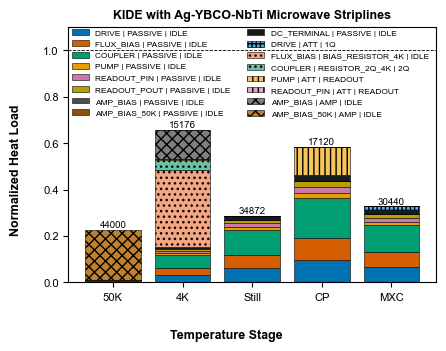

In [6]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4.5, 3.5))

df_plot = df.drop(columns=["Total"])
possible_physical_qubits = pq
title = title

# Columns: MultiIndex with levels (Cable, Component, Operation)
cols = list(df_plot.columns)

# Index: temperature stages (e.g., "4K", "Still", "CP", "MXC")
# X positions and labels (temperature stages)
x = np.arange(len(df_plot.index))
xticklabels = ["50K", "4K", "Still", "CP", "MXC" ]

# Create the figure/axes

# Build the stacked bars
bottom = np.zeros(len(x), dtype=float)

for i, col in enumerate(cols):
    values = df_plot[col].astype(float).values

    # pull style from style_map if present, else fallback
    style = style_map.get(col, {})
    color = style.get('color', fallback_color)
    hatch = style.get('hatch', fallback_hatch)

    # readable label in legend
    label = f"{col[0]} | {col[1]} | {col[2]}"

    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        label=label,
        color=color,
        edgecolor='black',
        linewidth=0.4
    )
    # apply hatch to each rectangle
    for b in bars:
        b.set_hatch(hatch)

    bottom += values  # update stack baseline


# Display no. of supported qubits on top of the bar
totals = df_plot.sum(axis=1)  # Sum over column. Get bar height
for i, total in enumerate(totals):
    ax.text(i, total, f'{possible_physical_qubits[i]}', ha='center', va='bottom', fontproperties=text_font)

# Draw horizantal line at y=1
ax.axhline(y=1, color='k', linestyle='--',linewidth=0.6)

# Axis cosmetics
# Set titles 
ax.set_title(title, fontproperties=axis_label_font)
# ax.set_xlabel("Temperature Stage", fontproperties=axis_label_font)
# ax.set_ylabel("Normalized Heat Load", fontproperties=axis_label_font)
ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontproperties=tick_label_font, rotation=0)
for label in ax.get_yticklabels() :
    label.set_fontproperties(tick_label_font)
ax.set_ylim(0, max(1.1,max(totals)*1.1)) # Set max y-value to be slightly higher than the tallest bar

# Legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
          ncol=2, 
          bbox_to_anchor=(0.15, 0.91), 
          loc='upper left',
          prop=legend_font,
          frameon=False,
          borderaxespad=0.)

# Axis Labels
fig.supxlabel('Temperature Stage',fontproperties=axis_label_font)
fig.supylabel('Normalized Heat Load', fontproperties=axis_label_font)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Save figure
plt.savefig(f"./kide-ybco-delft.png",dpi=600,bbox_inches='tight')